## 

# Projet d'Analyse de Données — Sleep Efficiency Dataset
### 4MA - INSA Toulouse 2025–2026

---

## Problématique

**Quels sont les facteurs comportementaux, physiologiques et démographiques qui structurent la qualité du sommeil, et peut-on identifier des profils typiques de dormeurs ?**

Nous étudions le jeu de données *Sleep Efficiency* disponible sur Kaggle ([lien](https://www.kaggle.com/datasets/equilibriumm/sleep-efficiency)), qui recense 452 individus décrits par leurs habitudes de sommeil, leur mode de vie et leurs paramètres physiologiques de sommeil.

**Démarche du projet :**
1. Évaluer la qualité du jeu de données (valeurs manquantes, aberrantes, redondances)
2. Réduction linéaire de dimension à l'aide de différentes méthodes d'analyse factorielle (ACP, LDA, FAMD)
3. Identifier des groupes homogènes de dormeurs via un **clustering** 
4. Interpréter les résultats en lien avec la problématique

**Justification du choix du dataset :**  
Ce jeu de données présente un mélange naturel de variables quantitatives continues et de variables qualitatives, ce qui en fait un cas d'usage idéal pour la FAMD. Le sommeil et ses liens avec le mode de vie constituent par ailleurs un sujet qui nous tient à cœur, en tant qu'étudiants attirés par les sciences humaines, ce dataset représente pour nous une occasion concrète de montrer comment les statistiques peuvent éclairer des comportements du quotidien.

### 0. Importation des bibliothèques 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

### 1. Chargement des données

#### 1.1 Description des variables :

Pour chaque individu, on observe les **15 variables** suivantes :

* `ID` : Identifiant unique de l'individu
* `Age` : Âge en années
* `Gender` : Genre de l'individu (Male / Female)
* `Bedtime` : Heure de coucher (format datetime)
* `Wakeup time` : Heure de réveil (format datetime)
* `Sleep duration` : Durée totale du sommeil en heures
* `Sleep efficiency` : Proportion du temps au lit effectivement passé à dormir (entre 0 et 1)
* `REM sleep percentage` : Part du sommeil passée en phase REM (Rapid Eye Movement) (%), correspondant à une phase de sommeil où l’activité cérébrale est élevée et où surviennent la majorité des rêves 
* `Deep sleep percentage` : Part du sommeil passée en sommeil profond (%)
* `Light sleep percentage` : Part du sommeil passée en sommeil léger (%)
* `Awakenings` : Nombre de réveils nocturnes
* `Caffeine consumption` : Quantité de caféine consommée dans les 24h précédant le coucher (mg)
* `Alcohol consumption` : Quantité d'alcool consommée dans les 24h précédant le coucher (en onces, oz)
* `Smoking status` : Statut tabagique de l'individu (Yes / No)
* `Exercise frequency` : Fréquence d'activité physique hebdomadaire (jours/semaine)


In [2]:
df = pd.read_csv('Sleep_Efficiency.csv')
display( 
    df.head().style.background_gradient(cmap='BuPu')
)
print("Dimensions:", df.shape)
df.info()
df.describe(include='all')


,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,1,65,Female,2021-03-06 01:00:00,2021-03-06 07:00:00,6.000000,0.880000,18,70,12,0.000000,0.000000,0.000000,Yes,3.000000
1,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.000000,0.660000,19,28,53,3.000000,0.000000,3.000000,Yes,3.000000
2,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.000000,0.890000,20,70,10,1.000000,0.000000,0.000000,No,3.000000
3,4,40,Female,2021-11-03 02:30:00,2021-11-03 08:30:00,6.000000,0.510000,23,25,52,3.000000,50.000000,5.000000,Yes,1.000000
4,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.000000,0.760000,27,55,18,3.000000,0.000000,3.000000,No,3.000000


Dimensions: (452, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      452 non-null    int64  
 1   Age                     452 non-null    int64  
 2   Gender                  452 non-null    object 
 3   Bedtime                 452 non-null    object 
 4   Wakeup time             452 non-null    object 
 5   Sleep duration          452 non-null    float64
 6   Sleep efficiency        452 non-null    float64
 7   REM sleep percentage    452 non-null    int64  
 8   Deep sleep percentage   452 non-null    int64  
 9   Light sleep percentage  452 non-null    int64  
 10  Awakenings              432 non-null    float64
 11  Caffeine consumption    427 non-null    float64
 12  Alcohol consumption     438 non-null    float64
 13  Smoking status          452 non-null    object 
 14  Exercise frequency  

,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
count,452.000000,452.000000,452,452,452,452.000000,452.000000,452.000000,452.000000,452.000000,432.000000,427.000000,438.000000,452,446.000000
unique,NaN,NaN,2,424,434,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,Male,2021-03-11 01:00:00,2021-05-08 07:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN
freq,NaN,NaN,228,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,298,NaN
mean,226.500000,40.285398,NaN,NaN,NaN,7.465708,0.788916,22.615044,52.823009,24.561947,1.641204,23.653396,1.173516,NaN,1.791480
std,130.625419,13.172250,NaN,NaN,NaN,0.866625,0.135237,3.525963,15.654235,15.313665,1.356762,30.202785,1.621377,NaN,1.428134
min,1.000000,9.000000,NaN,NaN,NaN,5.000000,0.500000,15.000000,18.000000,7.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,113.750000,29.000000,NaN,NaN,NaN,7.000000,0.697500,20.000000,48.250000,15.000000,1.000000,0.000000,0.000000,NaN,0.000000
50%,226.500000,40.000000,NaN,NaN,NaN,7.500000,0.820000,22.000000,58.000000,18.000000,1.000000,25.000000,0.000000,NaN,2.000000
75%,339.250000,52.000000,NaN,NaN,NaN,8.000000,0.900000,25.000000,63.000000,32.500000,3.000000,50.000000,2.000000,NaN,3.000000



Le jeu de données contient **452 observations** et **15 variables**, dont :

- **5 variables quantitatives(entières)** : ID, Age, REM, Deep et Light sleep percentage  
- **6 variables quantitatives(continues)** : Sleep duration, Sleep efficiency, Awakenings, Caffeine, Alcohol, Exercise frequency  
- **4 variables qualitatives**: Gender, Bedtime, Wakeup time, Smoking status  




#### 1.2 Nettoyage et préparation du dataset

Cette section a pour objectif de :
- Charger et inspecter le jeu de données
- Vérifier la qualité des données
- Identifier et traiter les valeurs manquantes
- Détecter et traiter les outliers


In [3]:
n_duplicated = df.duplicated().sum()
print(f"Number of duplicated rows: {n_duplicated}\n")

df_aux = pd.DataFrame({
    'n_unique':df.nunique(),
    'n_missing':df.isna().sum(),
    'missing_ratio':df.isna().mean(),
    'dtype':df.dtypes.values
})

display(
    df_aux.style.background_gradient(cmap='BuPu')
        .format({"missing_ratio": "{:.2%}"})
)

Number of duplicated rows: 0



,n_unique,n_missing,missing_ratio,dtype
ID,452,0,0.00%,int64
Age,61,0,0.00%,int64
Gender,2,0,0.00%,object
Bedtime,424,0,0.00%,object
Wakeup time,434,0,0.00%,object
Sleep duration,9,0,0.00%,float64
Sleep efficiency,50,0,0.00%,float64
REM sleep percentage,13,0,0.00%,int64
Deep sleep percentage,29,0,0.00%,int64
Light sleep percentage,29,0,0.00%,int64


Le tableau révèle 4 variables avec des valeurs manquantes, toutes inférieures à 6%, ces taux étant faibles, nous avons choisi de remplir ces valeurs manquantes plutôt que de supprimer les lignes concernées, afin de ne pas perdre d'information.

On note également que `Bedtime` et `Wakeup time` affichent une très haute cardinalité (424 et 434 valeurs uniques sur 452), ce qui confirme leur caractère quasi-individuel.

Aucun doublon n'a été détecté dans le jeu de données ce qui est confirmé par la variable `ID` qui présente bien 452 valeurs uniques.

##### 1.2.1 Suppression des colonnes redondantes

- La variable `ID` n'apportant aucune information est supprimée.
- Les variables `Bedtime` et `Wakeup time`, représentées sous forme de chaînes de caractères, sont redondantes avec `Sleep duration` qui capture déjà l'information essentielle. On extrait néanmoins une variable numérique `bedtime_hour` représentant l'heure du coucher, puis les deux colonnes originales sont supprimées.
- Concernant `bedtime_hour`, on récupère l'heure de la variable `Bedtime` uniquement, sans conserver la date complète: elle ne constitue pas une variable quantitative pertinente et ne peut pas non plus être traitée efficacement comme variable qualitative en raison de sa très forte cardinalité

In [4]:
#Création de la variable bedtime_hour
df['Bedtime'] = pd.to_datetime(df['Bedtime'])
df['bedtime_hour'] =df['Bedtime'].dt.hour + df['Bedtime'].dt.minute / 60



In [5]:
# Vérification des horaires de coucher (avant transformation)

# Entre minuit (0h) et midi (12h)
minuit_midi = ((df['bedtime_hour'] >= 0) & (df['bedtime_hour'] < 12)).sum()

# Entre midi (12h) et 20h
midi_20h = ((df['bedtime_hour'] >= 12) & (df['bedtime_hour'] < 20)).sum()

# Entre 20h et 23h59
vingt_24h = ((df['bedtime_hour'] >= 20) & (df['bedtime_hour'] < 24)).sum()

print("0h - 12h :", minuit_midi)
print("12h - 20h :", midi_20h)
print("20h - 24h :", vingt_24h)


0h - 12h : 241
12h - 20h : 0
20h - 24h : 211


L’analyse des horaires de coucher montre que les individus se couchent majoritairement entre 20h et minuit ou après minuit, tandis qu’aucune observation ne correspond à des heures comprises entre midi et 20h ; cela confirme le choix du seuil de 20h.

In [6]:
# Normalisation : les heures entre 20h et 23h59 deviennent négatives (avant minuit) afin de représenter la continuité temporelle (20h=−4, 23h=−1, 0h=0, 4h=4)
df['bedtime_hour'] = df['bedtime_hour'].apply(lambda h: h - 24 if h >= 20 else h)

cols_to_drop = ['ID', 'Bedtime', 'Wakeup time']
df.drop(columns=cols_to_drop, inplace=True)

Les heures de coucher comprises entre 20h et 23h59 ont été transformées en valeurs négatives (h − 24) afin de corriger la discontinuité autour de minuit, ce qui permet de représenter de manière plus cohérente la continuité des horaires de sommeil.   

##### 1.2.2 Gestion des valeurs manquantes

Les 4 variables concernées (`Awakenings`, `Caffeine consumption`, `Alcohol consumption`, `Exercise frequency`) présentent toutes un taux inférieur à 6% des valeurs manquantes. 


In [7]:
cols_to_impute = ['Awakenings', 'Caffeine consumption', 'Alcohol consumption', 'Exercise frequency']

for col in cols_to_impute:
    med_val = df[col].median()
    df[col] = df[col].fillna(med_val)


print("Vérification des valeurs manquantes :")
print(df.isnull().sum())

Vérification des valeurs manquantes :
Age                       0
Gender                    0
Sleep duration            0
Sleep efficiency          0
REM sleep percentage      0
Deep sleep percentage     0
Light sleep percentage    0
Awakenings                0
Caffeine consumption      0
Alcohol consumption       0
Smoking status            0
Exercise frequency        0
bedtime_hour              0
dtype: int64


##### 1.2.3 Détection des outliers

Nous utilisons des boxplots pour visualiser la distribution 
de chaque variable quantitative et repérer les valeurs aberrantes.

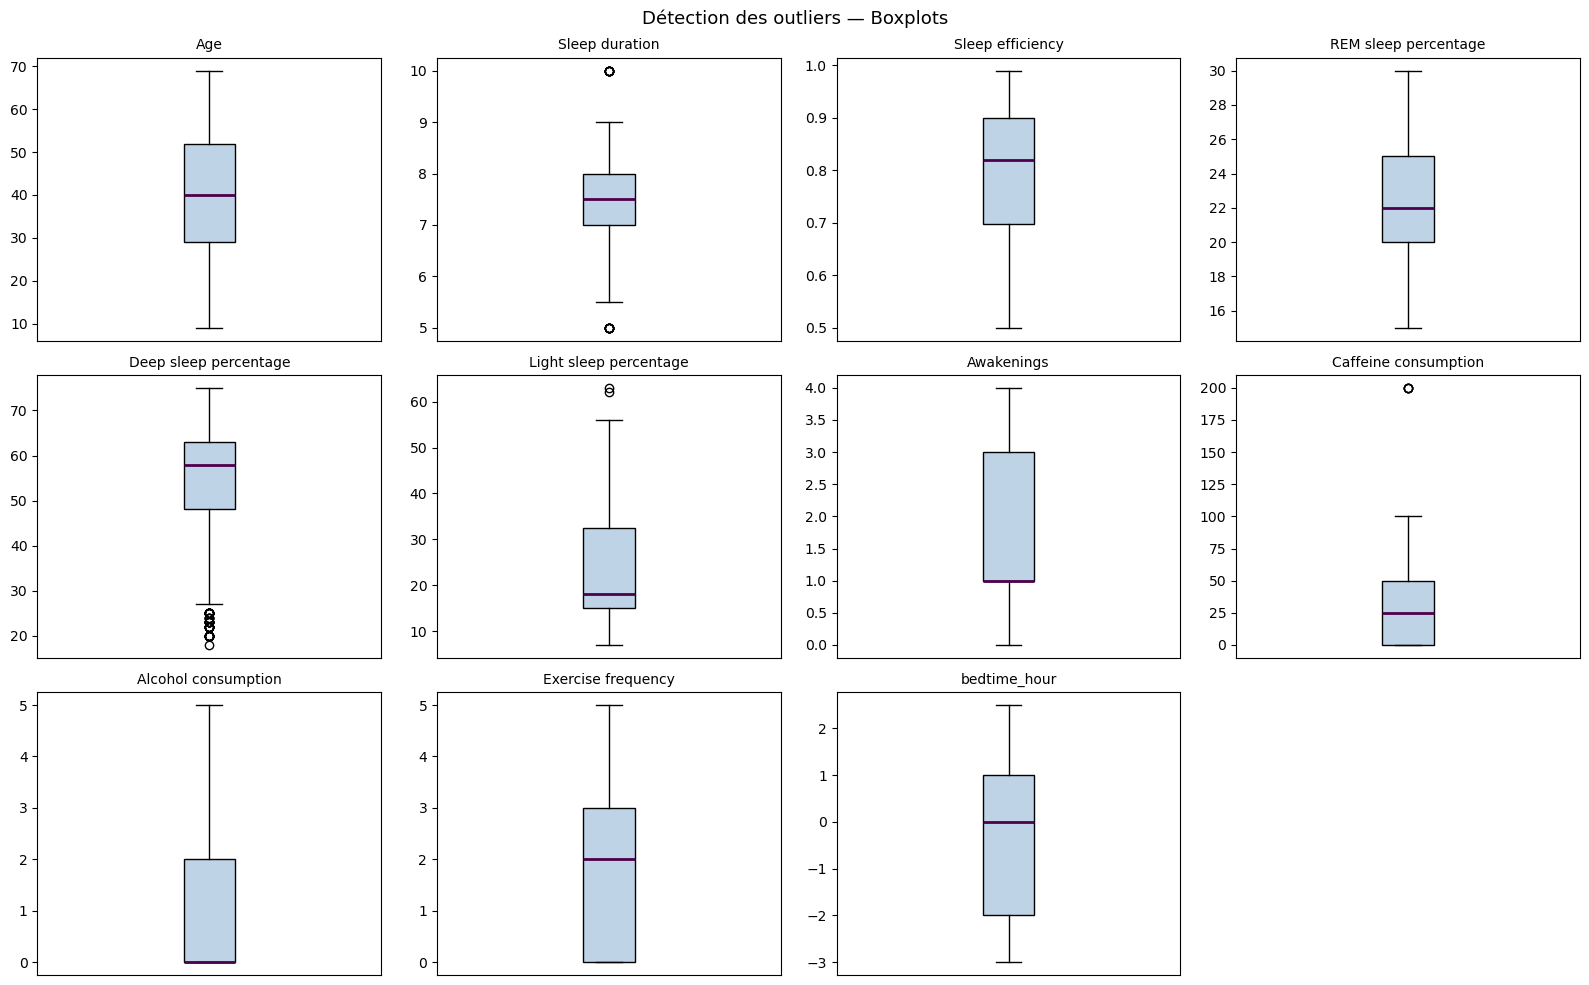

In [8]:
quant_cols = ['Age', 'Sleep duration', 'Sleep efficiency', 
              'REM sleep percentage', 'Deep sleep percentage',
              'Light sleep percentage', 'Awakenings', 
              'Caffeine consumption', 'Alcohol consumption', 
              'Exercise frequency', 'bedtime_hour']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(quant_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#BFD3E6'),
                    medianprops=dict(color='#4D004B', linewidth=2))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

# On cache le dernier subplot vide
axes[-1].set_visible(False)

plt.suptitle('Détection des outliers — Boxplots', fontsize=13)
plt.tight_layout()
plt.show()

Les boxplots montrent que les données sont globalement propres, avec très peu de valeurs extrêmes. La seule valeur notable est `Caffeine consumption` avec un individu à 200mg, une valeur élevée mais tout à fait réelle. Nous choisissons de la conserver telle quelle car elle reflète un comportement existant dans la population.

### 2.Analyse bidimensionnelle

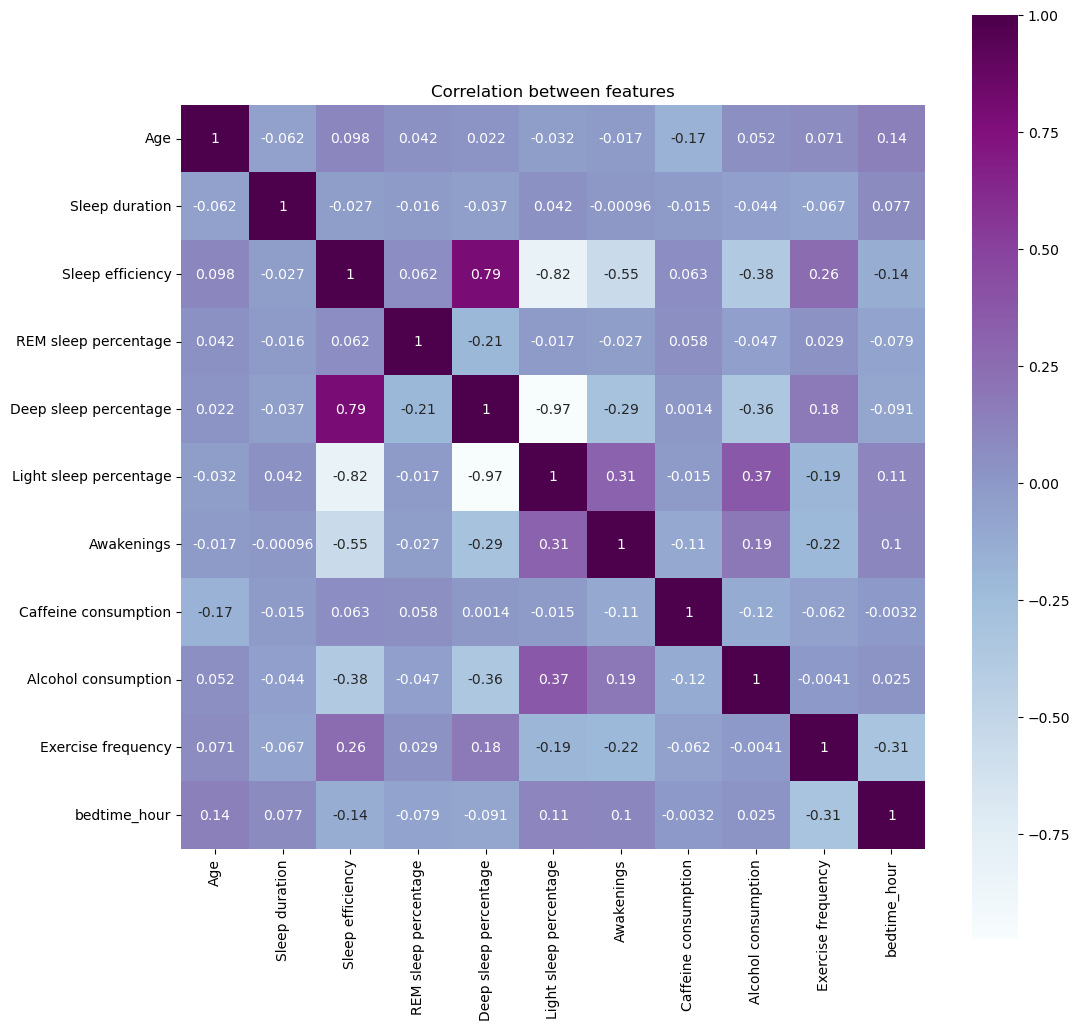

In [9]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, square=True, cmap='BuPu')
plt.title('Correlation between features')
plt.show()

La matrice de corrélation met en évidence plusieurs relations :

**Corrélations fortes :**
- `Deep sleep percentage` et `Light sleep percentage` sont très fortement corrélées négativement (-0.97), ce qui est logique car ces deux variables sont complémentaires, plus on passe de temps en sommeil profond, moins on passe de temps en sommeil léger. 
- `Sleep efficiency` et `Deep sleep percentage` sont fortement corrélées positivement (0.79), un sommeil plus profond est associé à une meilleure efficacité du sommeil.
- `Sleep efficiency` et `Light sleep percentage` sont fortement corrélées négativement (-0.82), plus on passe de temps en sommeil léger, moins le sommeil est efficace.

**Corrélations modérées :**
- `Awakenings` et `Sleep efficiency` (-0.55), se réveiller souvent
la nuit dégrade la qualité du sommeil.
- `Alcohol consumption` et `Sleep efficiency` (-0.38), la consommation
d'alcool est associée à une moins bonne qualité de sommeil.
- `Exercise frequency` et `bedtime_hour` (-0.31), les personnes qui
font plus de sport ont tendance à se coucher plus tôt.

**Le reste des variables** présente des corrélations faibles, ce qui
suggère qu'elles apportent des informations indépendantes et complémentaires.

### 3. Analyse en composantes pricipales (ACP)

In [14]:
import prince

# On récupère les variables quantitatives
X = df[quant_cols]

# PCA avec prince
pca = prince.PCA(
    n_components=3,
    n_iter=10,
    rescale_with_mean=True,
    rescale_with_std=True,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

# Fit du modèle
pca = pca.fit(X)

# Projection des données
projected = pca.transform(X)

print("--- PCA ---")
print(f"Initial dimension: {X.shape}")
print(f"Dimension after projection: {projected.shape}\n")

print("--- Explained variance ---")
summary = pca.eigenvalues_summary

for i in range(len(summary)):
    # On récupère la valeur brute (qui est déjà un texte comme "29.70%")
    percentage = summary.iloc[i, 1] 
    print(f"Component {i+1}: {percentage} of the total variance")

--- PCA ---
Initial dimension: (452, 11)
Dimension after projection: (452, 3)

--- Explained variance ---
Component 1: 29.70% of the total variance
Component 2: 12.10% of the total variance
Component 3: 11.47% of the total variance


Les variables étant exprimées dans des unités différentes, nous les centrons et réduisons afin qu'aucune variable ne domine les autres du fait de son échelle.

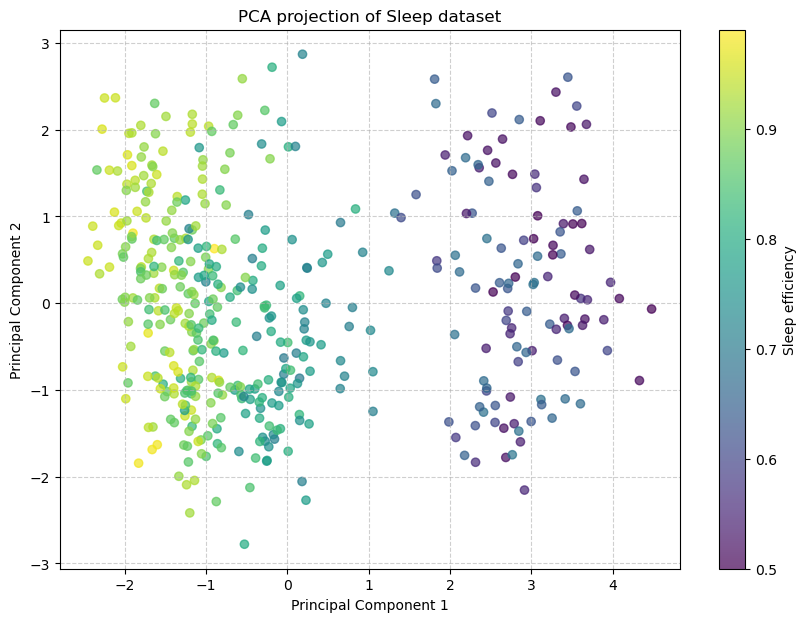

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Correction ici : on utilise .iloc pour accéder aux colonnes par position
plt.scatter(
    projected.iloc[:, 0], # Axe X (Composante 1)
    projected.iloc[:, 1], # Axe Y (Composante 2)
    c=df['Sleep efficiency'], # On prend la couleur dans le df d'origine
    cmap='viridis',
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA projection of Sleep dataset")

plt.colorbar(label="Sleep efficiency")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

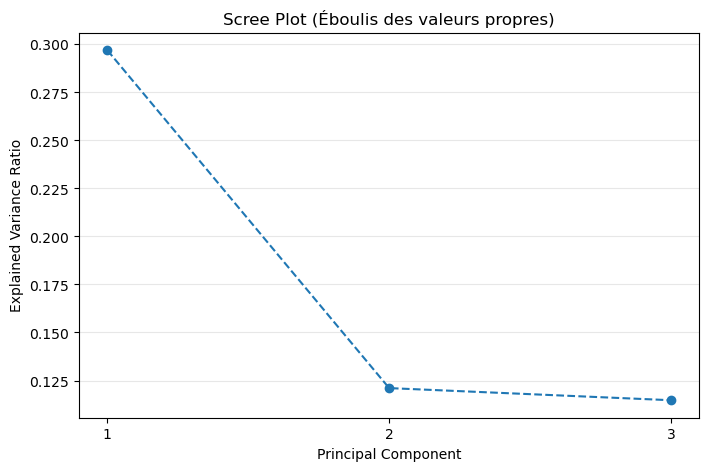

In [18]:

plt.figure(figsize=(8, 5))

# On récupère les pourcentages (Prince v0.13+)
# Si les valeurs sont > 1, on divise par 100 pour avoir un ratio entre 0 et 1
ratios = pca.percentage_of_variance_
if ratios[0] > 1:
    ratios = [r / 100 for r in ratios]

plt.plot(range(1, len(ratios) + 1), ratios, marker='o', linestyle='--')

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot (Éboulis des valeurs propres)")
plt.xticks(range(1, len(ratios) + 1)) # Pour afficher 1, 2, 3 sur l'axe X
plt.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
print("Variance cumulée :")
print(np.cumsum(ratios))

Variance cumulée :
[0.29695838 0.41800647 0.53274491]


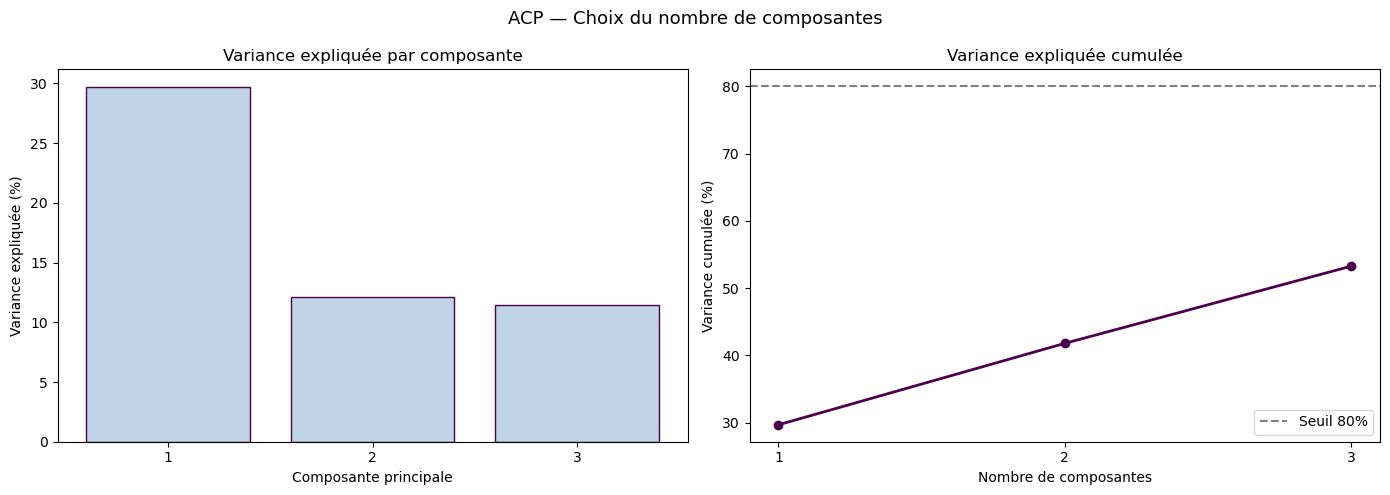

--- Résumé des Variances ---
PC1: 29.7%  (cumulé: 29.7%)
PC2: 12.1%  (cumulé: 41.8%)
PC3: 11.5%  (cumulé: 53.3%)


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 1. On utilise VOTRE objet 'pca' existant
explained_variance = np.array(pca.percentage_of_variance_)

# Sécurité : on s'assure d'être en pourcentages (Base 100) pour le graphique
if explained_variance[0] <= 1:
    explained_variance = explained_variance * 100

cumulative_variance = np.cumsum(explained_variance)

# 2. Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

# Histogramme variance expliquée (gauche)
ax1.bar(range(1, len(explained_variance)+1),
        explained_variance,
        color='#BFD3E6', edgecolor='#4D004B')

ax1.set_xlabel("Composante principale")
ax1.set_ylabel("Variance expliquée (%)")
ax1.set_title("Variance expliquée par composante")
ax1.set_xticks(range(1, len(explained_variance)+1))

# Variance cumulée (droite)
ax2.plot(range(1, len(cumulative_variance)+1),
         cumulative_variance,
         'o-', color='#4D004B', linewidth=2)

# Ligne des 80% (elle sera au-dessus de vos points actuels)
ax2.axhline(y=80, color='gray', linestyle='--', label="Seuil 80%")

ax2.set_xlabel("Nombre de composantes")
ax2.set_ylabel("Variance cumulée (%)")
ax2.set_title("Variance expliquée cumulée")
ax2.legend()
ax2.set_xticks(range(1, len(cumulative_variance)+1))

plt.suptitle("ACP — Choix du nombre de composantes", fontsize=13)
plt.tight_layout()
plt.show()

# Tableau récapitulatif
print("--- Résumé des Variances ---")
for i, (var, cum) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f"PC{i+1}: {var:.1f}%  (cumulé: {cum:.1f}%)")

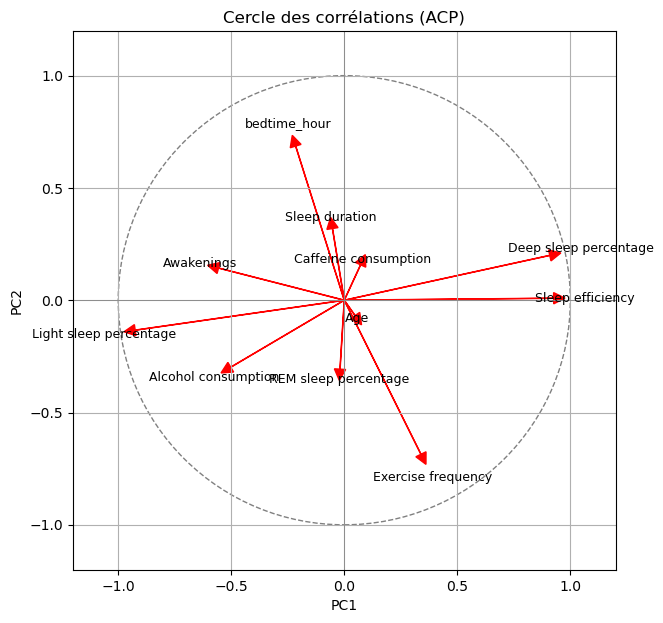

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1️⃣ Standardisation des variables (déjà faite pour ton PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[quant_cols].dropna())

# 2️⃣ ACP sur 2 composantes
pca = PCA(n_components=2)
projected = pca.fit_transform(X_scaled)

# 3️⃣ Récupérer les coordonnées des variables (flèches)
# loadings = corr(X_scaled, PC) = composantes * sqrt(variance)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# 4️⃣ Cercle des corrélations
plt.figure(figsize=(7,7))

# Cercle unité
circle = plt.Circle((0,0), 1, color='grey', fill=False, linestyle='--')
plt.gca().add_artist(circle)

# Flèches pour chaque variable
for i, var in enumerate(quant_cols):
    plt.arrow(0, 0, loadings[i,0], loadings[i,1],
              head_width=0.05, head_length=0.05, color='red')
    plt.text(loadings[i,0]*1.15, loadings[i,1]*1.15, var,
             color='black', ha='center', va='center', fontsize=9)

# Axes
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cercle des corrélations (ACP)")

plt.grid(True)
plt.show()



In [ ]:
#LDA 
#Dans cette partie, nous appliquons une analyse discriminante linéaire (LDA) afin de classer les individus en fonction de leur efficacité 
#de sommeil (Low, Medium, High). L’objectif est de trouver des axes discriminants qui maximisent la séparation entre ces classes et 
#d’évaluer la performance prédictive des variables quantitatives du dataset.







In [24]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

# 1️⃣ Créer les classes pour Sleep efficiency
bins = [0, 70, 85, 100]
labels = ['Low', 'Medium', 'High']
df['SleepClass'] = pd.cut(df['Sleep efficiency'], bins=bins, labels=labels)

# 2️⃣ Features et target
X = df[quant_cols]   # toutes les variables quantitatives
y = df['SleepClass']

# 3️⃣ Split train/test
train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.3, random_state=42)

# 4️⃣ LDA
clf = LinearDiscriminantAnalysis()
clf.fit(train_x, train_y)

# 5️⃣ Prédictions
train_pred = clf.predict(train_x)
test_pred  = clf.predict(test_x)

# 6️⃣ Évaluation
train_acc = accuracy_score(train_y, train_pred)
test_acc  = accuracy_score(test_y, test_pred)

print(f"Train accuracy: {train_acc:.2%}")
print(f"Test accuracy: {test_acc:.2%}\n")

print(classification_report(test_y, test_pred))

Train accuracy: 100.00%
Test accuracy: 100.00%

              precision    recall  f1-score   support

         Low       1.00      1.00      1.00       136

    accuracy                           1.00       136
   macro avg       1.00      1.00      1.00       136
weighted avg       1.00      1.00      1.00       136



In [25]:

# Vérifie min/max
print(df['Sleep efficiency'].min(), df['Sleep efficiency'].max())

# Créer 3 classes équilibrées
bins = [df['Sleep efficiency'].min()-1, 70, 85, df['Sleep efficiency'].max()+1]
labels = ['Low', 'Medium', 'High']
df['SleepClass'] = pd.cut(df['Sleep efficiency'], bins=bins, labels=labels)

# Vérifie que chaque classe contient des individus
print(df['SleepClass'].value_counts())

0.5 0.99


ValueError: bins must increase monotonically.

SleepClass
Low       452
Medium      0
High        0
Name: count, dtype: int64
